# Questão 4 — Dados Públicos

## Objetivo

Identificar produtos vendidos com prejuízo real, considerando:

- receita registrada em BRL no sistema de vendas
- custo unitário em USD no catálogo de importação
- conversão do custo para BRL com base na taxa de câmbio do dia da venda
- uso da última cotação disponível em dias sem câmbio (finais de semana e feriados)

## Premissas adotadas

- O custo em USD é unitário
- O custo total em BRL por transação considera a quantidade vendida
- O câmbio utilizado é a última cotação disponível menor ou igual à data da venda
- O prejuízo operacional ocorre quando o custo total da transação é maior do que a receita da transação
- O prejuizo por erro de precificação ocorre calculando +20% sobre o custo do produto
- Impostos e frete foram desconsiderados, conforme enunciado

## Camadas utilizadas

- `03_silver.int_vendas_enriquecidas`: base transacional enriquecida com custo e câmbio
- `04_gold.fct_prejuizo_produto`: agregação final por produto

## Parte 1 — Cálculo e modelagem

Nesta etapa, são apresentados:

1. o cálculo do custo total em BRL por transação  
2. a identificação de transações com prejuízo  
3. a agregação por produto com:
   - receita total
   - prejuízo total
   - percentual de perda

In [0]:
%sql
SELECT
    sale_id,
    customer_id,
    product_id,
    quantity,
    sale_date,
    receita_transacao_brl,
    usd_price,
    exchange_rate_date,
    exchange_rate,
    custo_unitario_brl,
    custo_total_brl,
    prejuizo_brl,
    teve_prejuizo
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
ORDER BY prejuizo_brl DESC
LIMIT 20;

sale_id,customer_id,product_id,quantity,sale_date,receita_transacao_brl,usd_price,exchange_rate_date,exchange_rate,custo_unitario_brl,custo_total_brl,prejuizo_brl,teve_prejuizo
5124,39,72,15,2024-11-23,1494970.0,30675.48,2024-11-22,5.8124,178298.15995200002,2674472.3992800005,1179502.3992800005,true
1414,45,72,13,2024-12-11,1295640.0,30675.48,2024-12-11,6.032,185034.49536,2405448.43968,1109808.4396799998,true
1564,16,72,15,2024-09-25,1420221.5,30675.48,2024-09-25,5.4736,167905.307328,2518579.6099199997,1098358.1099199997,true
4113,2,72,15,2024-08-22,1494970.0,30675.48,2024-08-22,5.5524,170322.535152,2554838.02728,1059868.02728,true
1914,28,72,11,2024-11-30,1041495.45,30675.48,2024-11-29,6.0535,185694.01817999998,2042634.1999799998,1001138.7499799998,true
515,28,83,10,2024-12-18,1280637.05,35839.7,2024-12-18,6.1624,220858.56728,2208585.6728,927948.6227999998,true
1727,40,72,14,2023-01-03,1395305.0,30675.48,2023-01-03,5.3759,164908.312932,2308716.381048,913411.381048,true
2653,25,83,13,2024-08-28,1664827.5,35839.7,2024-08-28,5.5315,198247.30054999999,2577214.90715,912387.4071499999,true
4941,45,72,14,2024-05-31,1395305.0,30675.48,2024-05-31,5.2416,160788.595968,2251040.343552,855735.3435519999,true
8172,46,72,12,2023-01-03,1136177.2,30675.48,2023-01-03,5.3759,164908.312932,1978899.755184,842722.5551839999,true


### Explicação da lógica transacional

A tabela `int_vendas_enriquecidas` foi construída com as seguintes regras:

- o custo histórico do produto foi selecionado pela data de vigência mais recente menor ou igual à data da venda
- a taxa de câmbio foi selecionada pela última data disponível menor ou igual à data da venda
- o custo total da transação foi calculado como:

`custo_total_brl = usd_price * exchange_rate * quantity`

- o prejuízo foi definido como:

`prejuizo_brl = custo_total_brl - receita_transacao_brl`, apenas quando o custo total superou a receita

In [0]:
%sql
SELECT
    id_produto,
    receita_total_brl,
    prejuizo_total_brl,
    percentual_perda
FROM lh_nautical.`04_gold`.fct_prejuizo_produto
ORDER BY prejuizo_total_brl DESC;

id_produto,receita_total_brl,prejuizo_total_brl,percentual_perda
72,6.305781564999998E7,3.982104167762E7,0.6315004931132595
83,4.437744E7,1.861429486502E7,0.41945400331835275
74,5.976435615000002E7,6716610.312960003,0.11238488533369735
71,8.156706665E7,6070816.059107995,0.07442729410826489
55,6.1224375E7,5371141.283277001,0.08772880545170124
91,6.6829268699999996E7,4883920.295391002,0.07308055871919188
63,6.88171859E7,4848430.376569999,0.07045377274821113
78,5.804373335000001E7,4171484.5119360015,0.07186795664541797
60,5.3418532E7,3183627.923214,0.059597817536693076
73,6.955425479999998E7,2988373.670562,0.04296464219413937


## Questão 4.1 — Código SQL

Abaixo está o SQL de agregação final por produto, contendo:

- receita total
- prejuízo total custo x receita
- prejuizo total potencial por erro na precificação
- percentual de perda

In [0]:
%sql
SELECT
    product_id AS id_produto,
    SUM(receita_transacao_brl) AS receita_total_brl,
    SUM(prejuizo_brl) AS prejuizo_total_brl,
    CASE
        WHEN SUM(receita_transacao_brl) = 0 THEN 0
        ELSE SUM(prejuizo_brl) / SUM(receita_transacao_brl)
    END AS percentual_perda
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
GROUP BY product_id
ORDER BY prejuizo_total_brl DESC;

id_produto,receita_total_brl,prejuizo_total_brl,percentual_perda
72,6.305781564999998E7,3.982104167762E7,0.6315004931132595
83,4.437744E7,1.861429486502E7,0.41945400331835275
74,5.976435615000002E7,6716610.312960003,0.11238488533369735
71,8.156706665E7,6070816.059107995,0.07442729410826489
55,6.1224375E7,5371141.283277001,0.08772880545170124
91,6.6829268699999996E7,4883920.295391002,0.07308055871919188
63,6.88171859E7,4848430.376569999,0.07045377274821113
78,5.804373335000001E7,4171484.5119360015,0.07186795664541797
60,5.3418532E7,3183627.923214,0.059597817536693076
73,6.955425479999998E7,2988373.670562,0.04296464219413937


In [0]:
%sql
SELECT
    SUM(prejuizo_total_operacional_brl) AS prejuizo_total_operacional,
    SUM(prejuizo_total_precificacao_brl) AS prejuizo_total_precificacao
FROM lh_nautical.04_gold.fct_prejuizo_produto;

prejuizo_total_operacional,prejuizo_total_precificacao
182226478.86,688542946.80400000


## Parte 2 — Análise visual

O gráfico abaixo apresenta o prejuízo total por produto, considerando apenas os produtos que registraram prejuízo no período analisado.

Observação: o produto 72 apresenta um valor muito superior aos demais, o que deve ser destacado na interpretação.

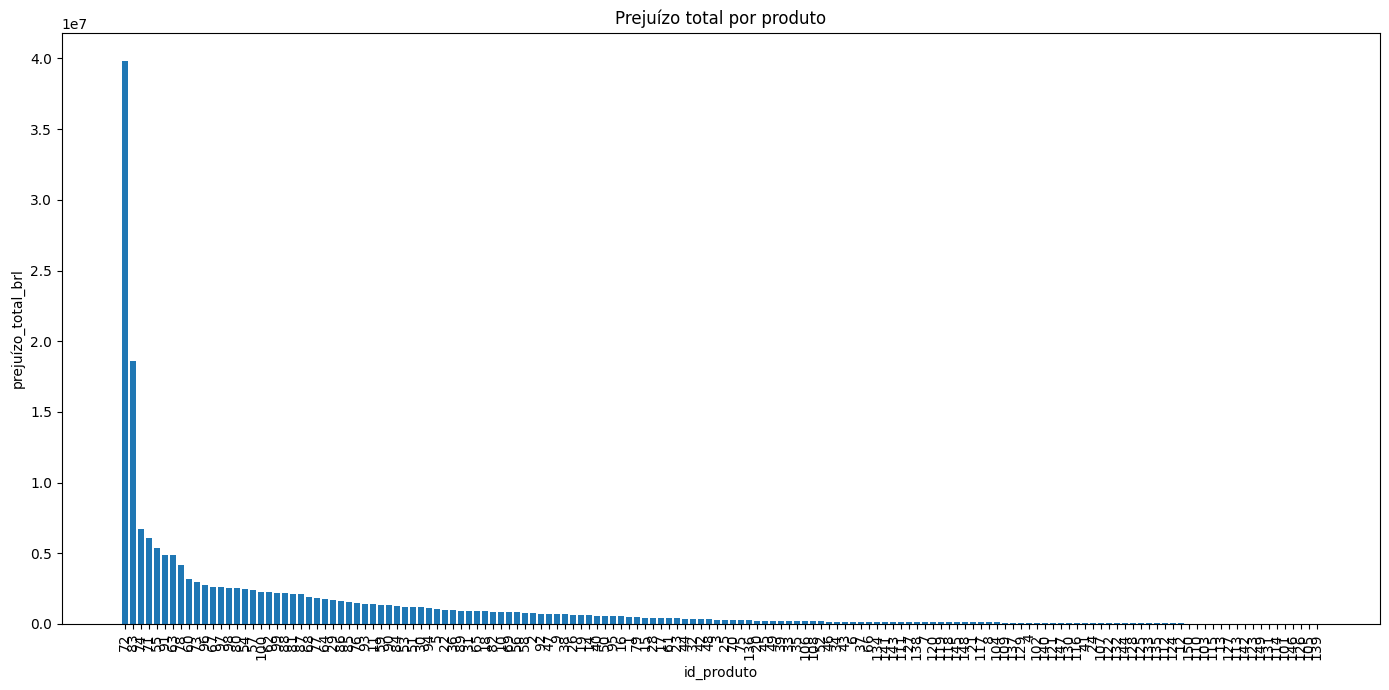

In [0]:
import matplotlib.pyplot as plt

# Leitura da tabela final
df_prejuizo = spark.table("lh_nautical.04_gold.fct_prejuizo_produto")

# Filtra apenas produtos com prejuízo
df_plot = (
    df_prejuizo
    .filter("prejuizo_total_brl > 0")
    .orderBy("prejuizo_total_brl", ascending=False)
    .toPandas()
)

# Criação do gráfico
plt.figure(figsize=(14, 7))
plt.bar(df_plot["id_produto"].astype(str), df_plot["prejuizo_total_brl"])

# Configurações do gráfico
plt.title("Prejuízo total por produto")
plt.xlabel("id_produto")
plt.ylabel("prejuízo_total_brl")
plt.xticks(rotation=90)
plt.tight_layout()

# Exibição
plt.show()

## Parte 3 — Análise objetiva

Nesta etapa, são respondidas objetivamente as perguntas do enunciado com base na tabela final agregada.

In [0]:
%sql
-- maior prejuízo absoluto

SELECT
    id_produto,
    receita_total_brl,
    prejuizo_total_brl,
    percentual_perda
FROM lh_nautical.`04_gold`.fct_prejuizo_produto
ORDER BY prejuizo_total_brl DESC
LIMIT 1;

id_produto,receita_total_brl,prejuizo_total_brl,percentual_perda
72,6.305781564999998E7,3.982104167762E7,0.6315004931132595


In [0]:
%sql
-- maior percentual de perda

SELECT
    id_produto,
    receita_total_brl,
    prejuizo_total_brl,
    percentual_perda
FROM lh_nautical.`04_gold`.fct_prejuizo_produto
ORDER BY percentual_perda DESC
LIMIT 1;

id_produto,receita_total_brl,prejuizo_total_brl,percentual_perda
72,6.305781564999998E7,3.982104167762E7,0.6315004931132595


In [0]:
%sql
SELECT
    product_id,

    -- Volume
    COUNT(*) AS total_transacoes,
    SUM(quantity) AS total_itens_vendidos,

    -- Receita e custo
    SUM(receita_transacao_brl) AS receita_total_brl,
    SUM(custo_total_brl) AS custo_total_brl,

    -- Prejuízo
    SUM(prejuizo_brl) AS prejuizo_total_brl,

    -- % de transações com prejuízo
    AVG(CASE WHEN teve_prejuizo THEN 1 ELSE 0 END) * 100 AS percentual_transacoes_com_prejuizo,

    -- Preço médio vs custo médio
    AVG(receita_transacao_brl / quantity) AS preco_medio_venda,
    AVG(custo_unitario_brl) AS custo_medio_unitario,

    -- Margem média por item
    AVG(
        (receita_transacao_brl / quantity) - custo_unitario_brl
    ) AS margem_unitaria_media,

    -- Prejuízo médio por item
    SUM(prejuizo_brl) / SUM(quantity) AS prejuizo_medio_por_item

FROM lh_nautical.04_gold.fct_vendas
WHERE product_id = 72
GROUP BY product_id;

product_id,total_transacoes,total_itens_vendidos,receita_total_brl,custo_total_brl,prejuizo_total_brl,percentual_transacoes_com_prejuizo,preco_medio_venda,custo_medio_unitario,margem_unitaria_media,prejuizo_medio_por_item
72,78,647,63057815.65,102878857.30,39821041.65,100.0,97173.03284653380806667,158751.075897,-61578.04305090208936923,61547.205023183926


In [0]:
%sql
SELECT
    product_id,
    product_name,
    product_price
FROM lh_nautical.04_gold.dim_produto
ORDER BY product_price DESC
LIMIT 10;

product_id,product_name,product_price
76,Motor Diesel Honda Aero 205HP,148198.23
73,Motor de Popa Torqeedo Core Hydra Flux 162HP,143159.93
63,Motor Elétrico Torqeedo Ion Orca Vox 186HP,139957.67
97,Motor de Popa Tohatsu Evo 168HP,135335.07
91,Motor Elétrico Tohatsu Zenith Oceanic 113HP,134886.02
83,Motor Diesel Yanmar Dash Nitro 184HP,134803.88
71,Motor Elétrico Torqeedo Pulse 300HP,130174.06
80,Motor de Popa Volvo Maré 69HP,129223.84
81,Motor Elétrico Torqeedo Barracuda Magnum Helix 101HP,122148.49
78,Motor Elétrico Honda Mako Axis 131HP,121761.56


## Respostas objetivas

### Qual produto concentra o maior prejuízo absoluto?
O produto **72** concentra o maior prejuízo absoluto no período analisado.

### O produto com maior prejuízo absoluto também é o que possui a maior porcentagem de perda?
**Sim.**

### Qual é o id_produto com maior porcentagem de perda financeira relativa?
O `id_produto` com maior porcentagem de perda financeira relativa é o **72**.

## Questão 4.2 — Validação

Com base na tabela agregada por produto, o `id_produto` que apresentou a maior porcentagem de perda financeira relativa no período analisado foi o **72**.

## Questão 4.3 — Interpretação

### Qual data de câmbio foi utilizada?
Foi utilizada a **última cotação disponível menor ou igual à data da venda**.

Isso significa que:
- em dias úteis com cotação, foi utilizada a cotação do próprio dia
- em finais de semana e feriados, foi utilizada a última cotação útil anterior

### Como o prejuízo foi definido?
O prejuízo foi definido quando o **custo total da transação em BRL** foi maior do que a **receita da transação em BRL**.

A fórmula utilizada foi:

`custo_total_brl = usd_price * exchange_rate * quantity`

e:

`prejuizo_brl = custo_total_brl - receita_transacao_brl`, quando o resultado foi positivo

### Alguma suposição relevante?
Sim. As principais suposições adotadas foram:

Apesar do produto 72 concentrar o maior prejuízo absoluto e relativo, o produto 83 também apresenta um nível crítico de perda, indicando possíveis problemas de precificação ou custo elevado, mesmo com menor volume financeiro.

o resultado mostra:
Produto 72 → prejuízo ≈ 39.8 milhões
Produto 83 → prejuízo ≈ 18.6 milhões

Após análise, podemos ver que 100% das transações dos produtos 72 e 83 ocorreram com prejuízo, evidenciando um problema estrutural de precificação. Isso indica que esses produtos estão sendo vendidos sistematicamente abaixo do custo, resultando em perdas financeiras recorrentes e significativas para a operação.

Observa-se na sequencia, que os produtos 74, 71 e 55 também apresentem percentuais de perda, embora muito menores em relação aos principais(72 e 83) . A análise detalhada revelou que a maioria de suas transações ocorre com prejuízo (74% a 99%).



Outros pontos:

- a ausência de cotação em finais de semana e feriados foi tratada com a última cotação útil anterior, O período de cambio buscado via api foi de : 01/12/2022 a 31/12/2024. O período necessário utilizado foi de 30/12/2022 a 31/12/2024. Considerei isso pois o dia 01/01/2023 foi um domingo.

- impostos e frete foram desconsiderados, conforme orientação do enunciado
- a base de câmbio foi expandida para incluir datas anteriores ao início das vendas, garantindo cobertura completa para o período analisado

### + Explorações

In [0]:
%sql
SELECT
    product_id,
    AVG(receita_transacao_brl / quantity) AS preco_medio,
    AVG(custo_unitario_brl) AS custo_medio,
    AVG((receita_transacao_brl / quantity) - custo_unitario_brl) AS margem_unitaria,
    AVG(
        ((receita_transacao_brl / quantity) - custo_unitario_brl)
        / (receita_transacao_brl / quantity)
    ) AS margem_percentual
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
WHERE product_id IN (72, 83)
GROUP BY product_id;

product_id,preco_medio,custo_medio,margem_unitaria,margem_percentual
72,97173.03284653385,158751.07552784614,-61578.04268131232,-0.6348146194851338
83,130974.25054170894,187331.34246863637,-56357.091926927445,-0.43144013171473855


In [0]:
%sql
SELECT
    product_id,
    COUNT(*) AS total_transacoes,
    SUM(CASE WHEN teve_prejuizo THEN 1 ELSE 0 END) AS com_prejuizo,
    SUM(CASE WHEN teve_prejuizo THEN 1 ELSE 0 END) / COUNT(*) AS proporcao_prejuizo
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
WHERE product_id IN (72, 83)
GROUP BY product_id;

product_id,total_transacoes,com_prejuizo,proporcao_prejuizo
72,78,78,1.0
83,44,44,1.0


In [0]:
%sql
SELECT
    product_id,
    COUNT(*) AS total_transacoes,
    SUM(CASE WHEN teve_prejuizo THEN 1 ELSE 0 END) AS com_prejuizo,
    ROUND(
        SUM(CASE WHEN teve_prejuizo THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS proporcao_prejuizo
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
WHERE product_id IN (74, 71, 55)
GROUP BY product_id
ORDER BY proporcao_prejuizo DESC;

product_id,total_transacoes,com_prejuizo,proporcao_prejuizo
55,74,73,0.99
71,78,66,0.85
74,85,63,0.74


In [0]:
%sql
SELECT
    product_id,
    COUNT(*) AS total_transacoes,
    SUM(CASE WHEN teve_prejuizo THEN 1 ELSE 0 END) AS qtd_prejuizo,
    SUM(CASE WHEN NOT teve_prejuizo THEN 1 ELSE 0 END) AS qtd_lucro
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
WHERE product_id IN (74, 71, 55)
GROUP BY product_id;

product_id,total_transacoes,qtd_prejuizo,qtd_lucro
71,78,66,12
74,85,63,22
55,74,73,1


In [0]:
%sql
SELECT
    product_id,
    AVG((receita_transacao_brl / quantity) - custo_unitario_brl) AS margem_unitaria_media
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
WHERE product_id IN (74, 71, 55)
GROUP BY product_id;

product_id,margem_unitaria_media
71,-8583.277799096513
74,-7862.527362843451
55,-9798.444610233277


In [0]:
%sql
SELECT
    product_id,
    MIN(prejuizo_brl) AS min_prejuizo,
    MAX(prejuizo_brl) AS max_prejuizo,
    AVG(prejuizo_brl) AS avg_prejuizo
FROM lh_nautical.`03_silver`.int_vendas_enriquecidas
WHERE product_id IN (74, 71, 55)
GROUP BY product_id;

product_id,min_prejuizo,max_prejuizo,avg_prejuizo
71,0.0,472923.56169999973,77830.97511676916
74,0.0,495908.4571150001,79018.94485835297
55,0.0,277647.049568,72582.99031455407


In [0]:
%sql
SELECT
    product_id,
    COUNT(*) AS qtd
FROM lh_nautical.02_bronze.produtos_bronze
GROUP BY product_id
HAVING COUNT(*) > 1
ORDER BY qtd DESC, product_id;

product_id,qtd
62,4
145,3
37,2
127,2


In [0]:
%sql
select
    sum(receita_transacao_brl) as receita_total,
    sum(custo_total_brl) as custo_total,
    sum(prejuizo_brl) as prejuizo_total
from lh_nautical.04_gold.fct_vendas;

receita_total,custo_total,prejuizo_total
2610279510.70,2749018499.62,182226478.86
